# 학생 증류 모델(`c4f_distill_11n_640`) — `test_real_data` 추론 확인

`data/own_night`(`test_real_data` 7장 + `test_real_data2` 20장 · 라벨 있음)에서
**`test_real_data` 유래 7장만** 골라, 학생 증류 모델의 예측을 확인한다.
라벨이 이미 `own_night`에 채워져 있으므로 예측과 함께 GT도 같이 감사한다.

- 지표(mAP 등) 비교는 `c5_own_night_review.ipynb`(4자 비교)의 몫이다 — 여기는 학생 모델
  단독의 **정성 확인**(예측 시각화 + GT 감사)만 한다.
- 렌더는 배포와 같은 `emphasize.draw_emphasis`를 쓴다.

In [1]:
import os, sys
from pathlib import Path

os.environ.setdefault("YOLO_AUTOINSTALL", "false")   # -> STATUS 3장 함정 9
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "scripts"))

import json
import cv2
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from ultralytics import YOLO

import eval_own_night as C5                      # load_samples 재사용
from eval_real_night import SCENE, scene_of       # 장면 이름표 재사용
from emphasize import from_ultralytics, draw_emphasis, Detection

_have = {f.name for f in matplotlib.font_manager.fontManager.ttflist}
for _f in ("Malgun Gothic", "AppleGothic", "NanumGothic"):
    if _f in _have:
        plt.rcParams["font.family"] = _f
        break
plt.rcParams["axes.unicode_minus"] = False

In [2]:
WEIGHTS = {"c4f_distill_11n_640": ROOT / "outputs/detect/c4f_distill_11n_640/weights/best.pt"}
CONF, IMGSZ, IOU = 0.25, 640, 0.5

SRC = ROOT / "data/own_night"
samples = C5.load_samples(SRC, ignore_id=3)
samples7 = [s for s in samples if s.stem.startswith("KakaoTalk_20260808_220234014")]

print(f"test_real_data 유래 {len(samples7)}장 (전체 own_night {len(samples)}장 중)")
for s in samples7:
    print(f"  {s.stem:<32} {scene_of(s.stem):<10} GT {len(s.gt)}개")

test_real_data 유래 7장 (전체 own_night 27장 중)
  KakaoTalk_20260808_220234014     negative   GT 0개
  KakaoTalk_20260808_220234014_01  negative   GT 0개
  KakaoTalk_20260808_220234014_02  negative   GT 0개
  KakaoTalk_20260808_220234014_03  negative   GT 1개
  KakaoTalk_20260808_220234014_04  bollard    GT 2개
  KakaoTalk_20260808_220234014_05  stairs     GT 1개
  KakaoTalk_20260808_220234014_06  negative   GT 0개


## 성능 비교 — `own_night` 27장 4자 비교 (교사·학생·`c4e_s3_11n`·INT8)

`scripts/eval_own_night.py` CLI로 이미 낸 `outputs/detect/c5_own_night_distill.json`을
그대로 읽어 표로만 정리한다(재계산 없음). 대상은 27장 전체(자체 촬영 야간분) 기준이고,
아래 예측 시각화(7장)와는 표본 범위가 다르다 — 여기는 **성능 판단**, 아래는 학생 모델의
**정성 확인**이다.

In [3]:
cached = json.load(open(ROOT / "outputs/detect/c5_own_night_distill.json", encoding="utf-8"))
cached_rows = {r["run"]: r for r in cached["rows"]}   # conf 0.25 단일 grid라 run당 1행

order = [C5.CLASS_NAMES[0], C5.CLASS_NAMES[1], C5.CLASS_NAMES[2], "종합"]
map_rows = {}
for name, info in cached["runs"].items():
    row = {cls: v["ap50"] for cls, v in info["map"]["per_class"].items()}
    row["종합"] = info["map"]["map50"]
    map_rows[name] = row
map_df = pd.DataFrame(map_rows).T[order]
print(f"축 A. mAP50 (conf 무관) — own_night {cached['n_images']}장")
display(map_df.round(3))

축 A. mAP50 (conf 무관) — own_night 27장


,person,stairs,bollard,종합
c4f_11s_640_teacher,0.995,0.165,0.640,0.600
c4f_distill_11n_640,0.995,0.076,0.591,0.554
bammasil_det_c4e_s3_11n_640,0.995,0.047,0.527,0.523
bammasil_det_c4e_s3_11n_640-INT8,0.995,0.047,0.535,0.525


In [4]:
rows = [{"run": name, "class": cls, **v}
        for name, r in cached_rows.items() for cls, v in r["ops"].items()]
ops_df = pd.DataFrame(rows).set_index(["run", "class"])[["recall", "precision", "f1", "tp", "fp", "fn"]]
print(f"축 B. 운영점(conf {cached['rows'][0]['conf_label']}) recall/precision/F1")
display(ops_df.round(3))

축 B. 운영점(conf 0.25) recall/precision/F1


recall  precision     f1  tp  fp  fn
run                              class                                        
c4f_11s_640_teacher              person    1.000      0.667  0.800   4   2   0
                                 stairs    0.000      0.000    NaN   0   5   6
                                 bollard   0.846      0.846  0.846  11   2   2
                                 종합        0.652      0.625  0.638  15   9   8
c4f_distill_11n_640              person    1.000      0.800  0.889   4   1   0
                                 stairs    0.000      0.000    NaN   0   6   6
                                 bollard   0.846      0.688  0.759  11   5   2
                                 종합        0.652      0.556  0.600  15  12   8
bammasil_det_c4e_s3_11n_640      person    1.000      0.800  0.889   4   1   0
                                 stairs    0.167      0.167  0.167   1   5   5
                                 bollard   0.846      0.688  0.759  11   5   2
                                 종합        0.696      0.593  0.640  16  11   7
bammasil_det_c4e_s3_11n_640-INT8 person    1.000      1.000  1.000   4   0   0
                                 stairs    0.167      0.167  0.167   1   5   5
                                 bollard   0.923      0.750  0.828  12   4   1
                                 종합        0.739      0.654  0.694  17   9   6

In [5]:
rows = [{"run": name, **r["negative"]["종합(전 프레임)"]} for name, r in cached_rows.items()]
neg_df = pd.DataFrame(rows).set_index("run").rename(
    columns={"n_frame": "음성프레임", "fp_box": "오탐박스", "hit_frame": "발화프레임"})
print("축 C. 음성 프레임 오탐 (전 프레임 기준)")
display(neg_df)

축 C. 음성 프레임 오탐 (전 프레임 기준)


,음성프레임,오탐박스,발화프레임
run,,,
c4f_11s_640_teacher,27,2,2
c4f_distill_11n_640,27,5,5
bammasil_det_c4e_s3_11n_640,27,4,4
bammasil_det_c4e_s3_11n_640-INT8,27,4,4


## 예측 시각화

학생 증류 모델의 예측을 7장에 그린다(한 장씩 predict — 함정 18).

In [6]:
model = YOLO(str(WEIGHTS["c4f_distill_11n_640"]))

pred_cache = {}
for s in samples7:
    r = model.predict(source=str(s.img), conf=CONF, imgsz=IMGSZ, device="cpu",
                      rect=False, verbose=False)[0]           # 한 장씩 · square (-> 함정 18)
    pred_cache[s.stem] = r
print(f"예측 완료 — {len(pred_cache)}장")

C:\Users\playdata2\Documents\KDT_Hackathon\.venv\Lib\site-packages\torch\cuda\__init__.py:1170: UserWarning: cudaGetDeviceCount() returned cudaErrorNotSupported, likely using older driver or on CPU machine (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\c10\cuda\CUDAFunctions.cpp:88.)
  r = torch._C._cuda_getDeviceCount() if nvml_count < 0 else nvml_count


예측 완료 — 7장


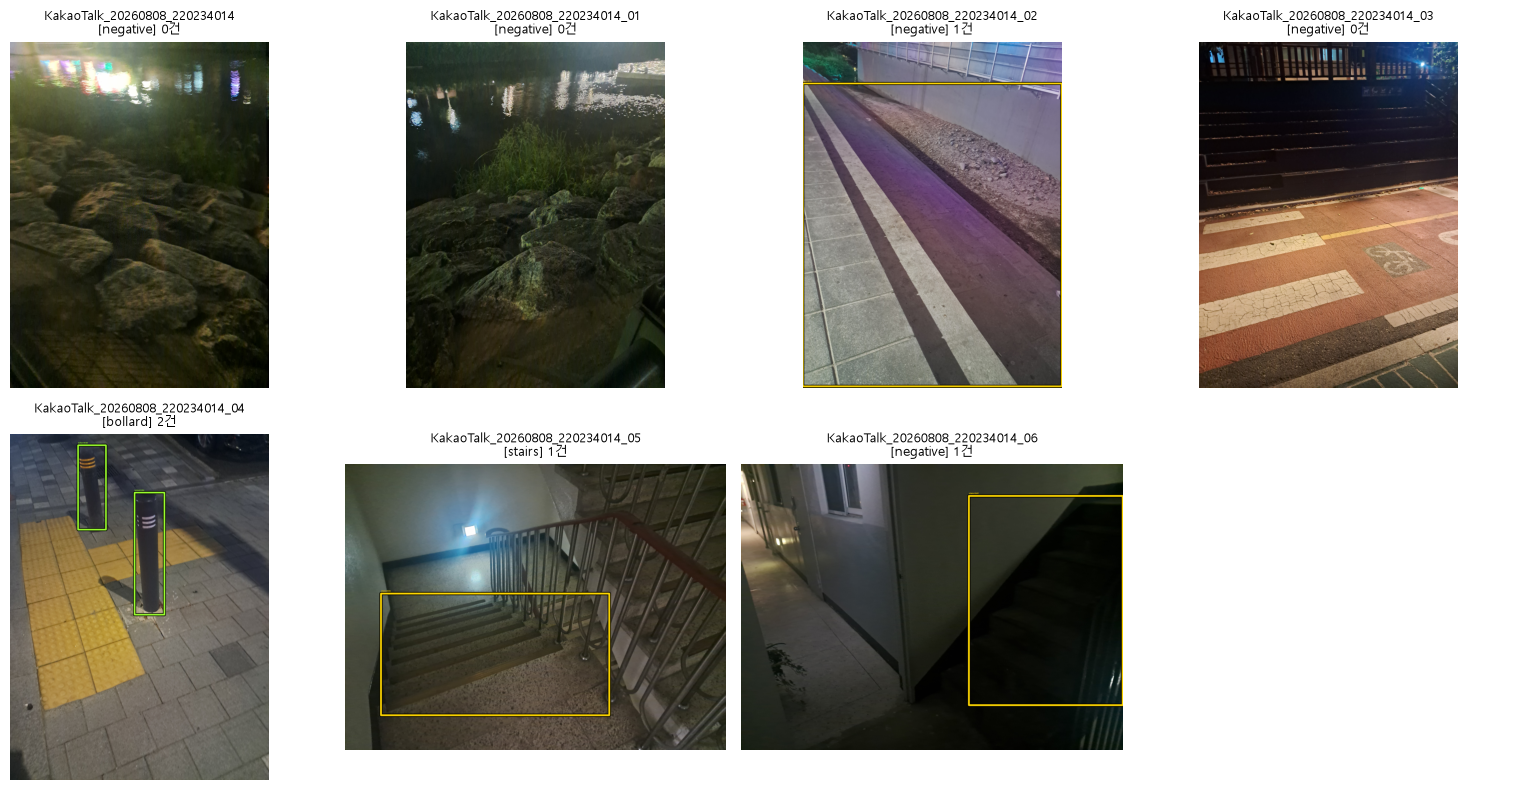

In [7]:
def show_predictions(samples, ncols=4, tile=4.0):
    nrows = -(-len(samples) // ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(tile * ncols, tile * nrows))
    axes = np.atleast_1d(axes).flatten()
    for ax, s in zip(axes, samples):
        r = pred_cache[s.stem]
        dets = from_ultralytics(r, min_conf=CONF)
        frame = draw_emphasis(r.orig_img.copy(), dets, min_conf=CONF, labels=True)
        ax.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        ax.set_title(f"{s.stem}\n[{scene_of(s.stem)}] {len(dets)}건", fontsize=9)
        ax.axis("off")
    for ax in axes[len(samples):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()


show_predictions(samples7)

## GT 라벨 감사 — `test_real_data` 7장

예측이 아니라 **`own_night`에 채워진 정답 라벨**을 그린다(색은 `emphasize.PALETTE`와 동일 ·
흰 박스 = `ignore`).

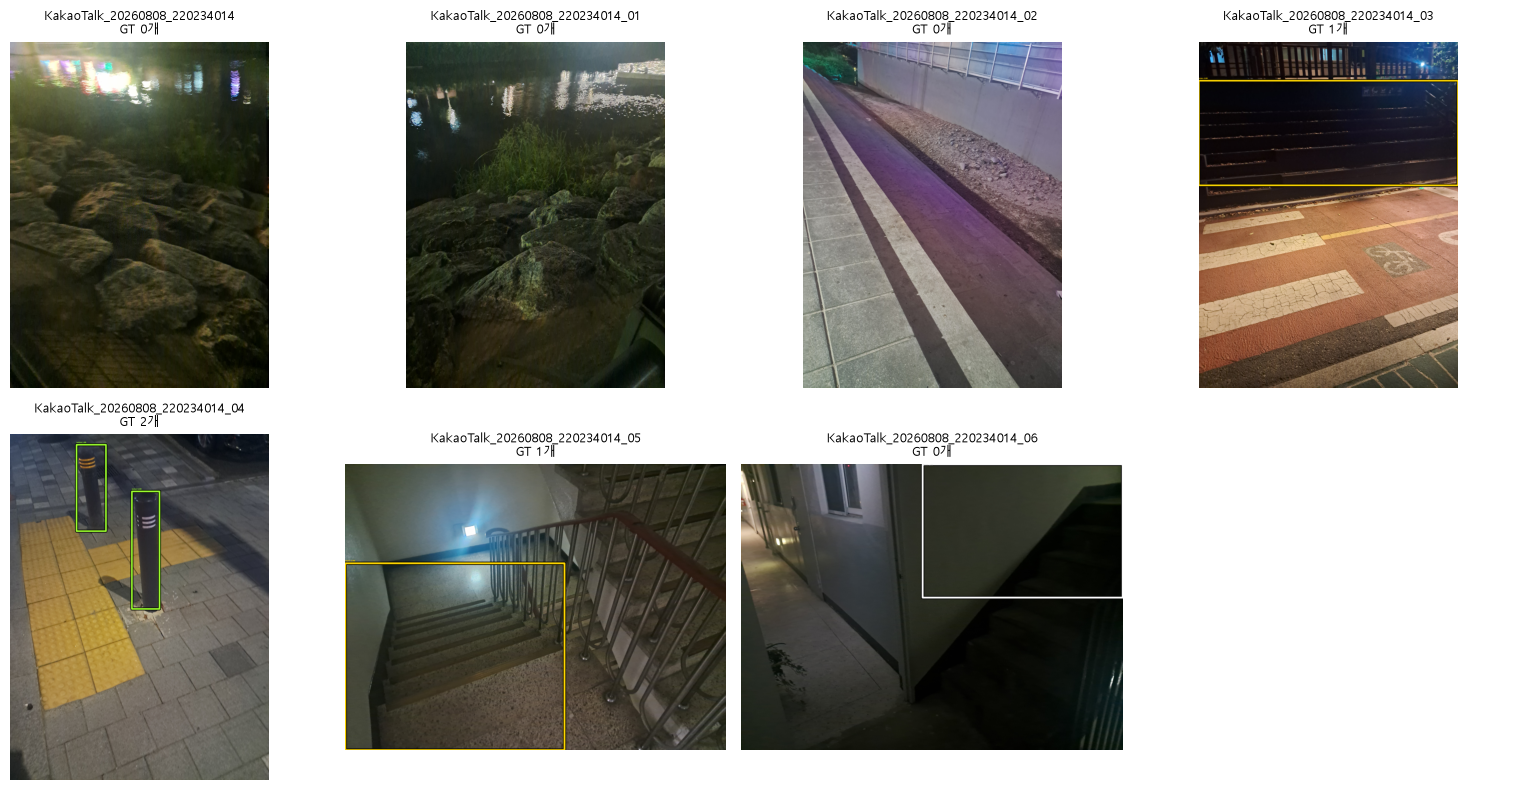

In [8]:
def show_gt_grid(samples, ncols=4, tile=4.0):
    nrows = -(-len(samples) // ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(tile * ncols, tile * nrows))
    axes = np.atleast_1d(axes).flatten()
    for ax, s in zip(axes, samples):
        im = cv2.imdecode(np.fromfile(str(s.img), np.uint8), cv2.IMREAD_COLOR)   # -> 함정 12
        dets = [Detection(C5.CLASS_NAMES[cid], 1.0, (int(x1), int(y1), int(x2), int(y2)))
                for cid, x1, y1, x2, y2 in s.gt]
        dets += [Detection("ignore", 1.0, tuple(int(v) for v in box)) for box in s.ign]
        frame = draw_emphasis(im, dets, min_conf=0.0, labels=True)
        ax.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        ax.set_title(f"{s.stem}\nGT {len(s.gt)}개", fontsize=9)
        ax.axis("off")
    for ax in axes[len(samples):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()


show_gt_grid(samples7)